## `emulate_hsc.ipynb` 

This notebook simulates how we extract from Buzzard Mocks an HSC-type catalog by mimicking the selection of HSC.

Idea :
- Bin HSC sources on a high-resolution healpix map to infer source density
- Draw N sources respecting the catalog magnitude distributions
- Assert it is correct by comparing to the true catalog 

## Step 1 : Binning HSC sources on a healpix map

In [35]:
import fitsio as fio 
import numpy as np 
import pandas as pd 
import healpy as hp
import cmocean.cm as cmo
import matplotlib.pyplot as plt

from pathlib import Path

HSC_CATALOG = Path(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
)
buzzard_index = 0
ROOT_BUZZARD = Path(
    f'/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0/buzzard-{buzzard_index}/addgalspostprocess'
    )
TRUTH = ROOT_BUZZARD / 'truth'
DESI_TGTS = ROOT_BUZZARD / 'desi_targets_v1.2'
MAGS = ROOT_BUZZARD / 'surveymags'

OUTPUT_SIM = Path(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/hsc_sim.fits'
)

class BuzzardCatalog():
    def __init__(self, buzzard_index, area='NW'):
        self.nside_buzzard = 8
        self.buzzard_index = buzzard_index
        self.ROOT_ALL = Path(
            '/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0'
            )
        self.ROOT_BUZZARD = Path(
            self.ROOT_ALL,
            f'buzzard-{self.buzzard_index}/addgalspostprocess'
            )
        self.TRUTH = ROOT_BUZZARD / 'truth'
        self.DESI_TGTS = ROOT_BUZZARD / 'desi_targets_v1.2'
        self.MAGS = ROOT_BUZZARD / 'surveymags'
        self.area = area
        
        listpix = self.TRUTH.glob('Chinchilla-11_cam_rs_scat_shift_lensed.*.fits')
        pix_nums = sorted([int(pix.name.split('.')[1]) for pix in listpix])

        self.pix_map = {}
        if area not in ['NW', 'NE', 'SW', 'SE']:
            raise ValueError(f'Area {area} not recognized. Choose from NW, NE, SW, SE')
        
        self.pix_map = {
            self.transform_pixels(
                i, 
                ra_flip=False if area in ['NW', 'SW'] else True,
                dec_flip=False if area in ['NW', 'NE'] else True
                ) : i for i in pix_nums
        }
            
    def fetch_truth(self, pix):
        return Path(
            self.TRUTH, 
            f'Chinchilla-{self.buzzard_index}_cam_rs_scat_shift_lensed.{pix}.fits'
            )
    
    def fetch_surveymag(self, pix):
        return Path(
            self.MAGS,
            f'surveymags-aux.{pix}.fits'
        )

    def fetch_desi_target(self, pix):
        return Path(
            self.DESI_TGTS,
            f'Chinchilla-0_cam_rs_scat_shift_lensed.{pix}.fits'
        )
    
    def transform_pixels(self, sim_pixels, ra_flip=False, dec_flip=False):
        theta, phi = hp.pix2ang(self.nside_buzzard, sim_pixels, nest=True)
        if ra_flip:
            phi = (phi + np.pi) % (2 * np.pi)
        if dec_flip:
            theta = np.pi - theta
        return hp.ang2pix(self.nside_buzzard, theta, phi, nest=True)

def which_area(ra, dec, index=False):
    if ra < 180:
        if index:
            return 0 if dec > 0 else 1
        return 'NW' if dec > 0 else 'SW'
    else:
        if index:
            return 2 if dec > 0 else 3
        return 'NE' if dec > 0 else 'SE'

In [10]:
## Get HSC coordinates
hsc_tbl = fio.FITS(HSC_CATALOG)
ra = hsc_tbl[1]['RA'].read()
dec = hsc_tbl[1]['DEC'].read()

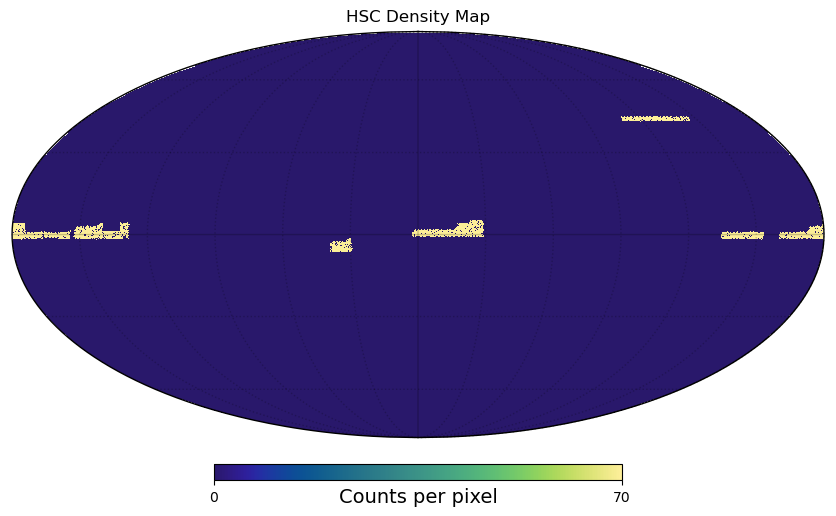

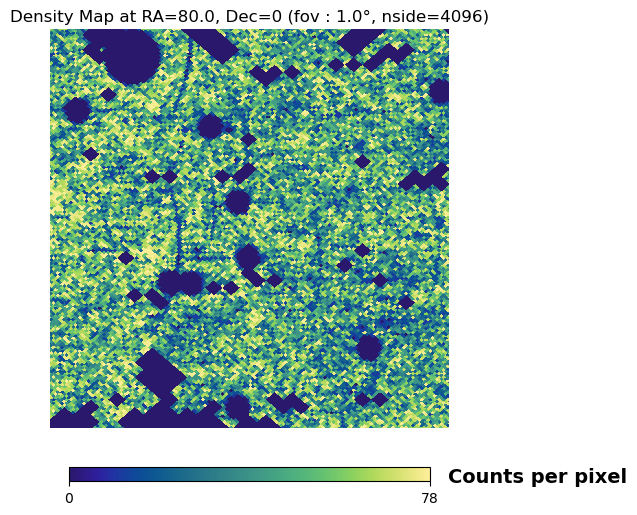

In [11]:
nside_hsc = 4096
npix_hsc = hp.nside2npix(nside_hsc)
theta = np.radians(90.0 - dec) 
phi = np.radians(ra)
hsc_pix_indices = hp.ang2pix(nside_hsc, theta, phi, nest=True)
hsc_hp_map = np.bincount(hsc_pix_indices, minlength=npix_hsc)

# === Zoom configuration ===
center_ra = 80.0  
center_dec = 0
half_width = 1.0
# ==========================

hp.mollview(
    hsc_hp_map,
    title="HSC Density Map",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
)
hp.graticule(alpha=0.2)
plt.show()
hp.cartview(
    hsc_hp_map,
    lonra=[center_ra - half_width, center_ra + half_width],
    latra=[center_dec - half_width, center_dec + half_width],
    rot=(center_ra, center_dec),
    title=f"Density Map at RA={center_ra}, Dec={center_dec} (fov : {half_width}°, nside={nside_hsc})",
    unit="Counts per pixel",
    norm="hist",
    cmap=cmo.haline,
    nest=True,
    cbar=True,
)

In [12]:
i_mag = hsc_tbl[1]['i_cm_mag'].read()
i_mag_nonnan = i_mag[~np.isnan(i_mag)]

In [13]:
i_mag_aperture = hsc_tbl[1]['i_aperture_mag'].read()

Text(0.5, 1.0, 'HSC true i-band magnitude distribution')

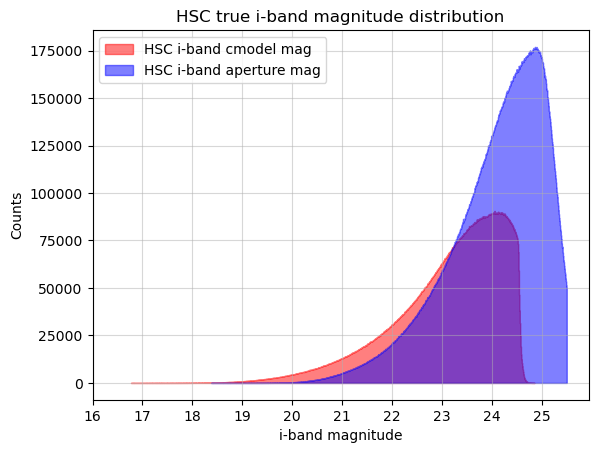

In [14]:
## Get the magnitude distribution in i-band
bins = 1000

counts_ihsc, bin_edges_ihsc = np.histogram(i_mag_nonnan, bins=bins)
bin_centers = 0.5 * (bin_edges_ihsc[:-1] + bin_edges_ihsc[1:])
plt.fill_between(
    bin_centers, counts_ihsc, step='mid', alpha=0.5, color='red', label='HSC i-band cmodel mag'
)

counts_ihsc_aperture, bin_edges_ihsc_aperture = np.histogram(i_mag_aperture, bins=bins)
bin_centers_aperture = 0.5 * (bin_edges_ihsc_aperture[:-1] + bin_edges_ihsc_aperture[1:])
plt.fill_between(
    bin_centers_aperture, counts_ihsc_aperture, step='mid', alpha=0.5, color='blue', label='HSC i-band aperture mag'
)
plt.xlabel("i-band magnitude")
plt.ylabel("Counts")
plt.legend()
plt.grid(True, alpha=0.5)
plt.xticks(ticks=np.arange(16, 26, 1))
plt.title("HSC true i-band magnitude distribution")

## Magnitude sampling

Following curves and nan magnitudes, let's go with i_aperture_mag as our fiducial magnitude to draw samples from. Let's first plot the distribution of magnitudes from Buzzard.

In [15]:
# Lensed magnitude
bc = BuzzardCatalog(buzzard_index=0)
pix = 0
mag = fio.FITS(bc.fetch_surveymag(pix=pix))
true = fio.FITS(bc.fetch_truth(pix=pix))
filters = np.loadtxt('filters.txt', dtype=str)
mag_index = list(filters).index('DECAM_i')
lens_ap_mag_i = true[1]['LMAG'].read()[:, mag_index]

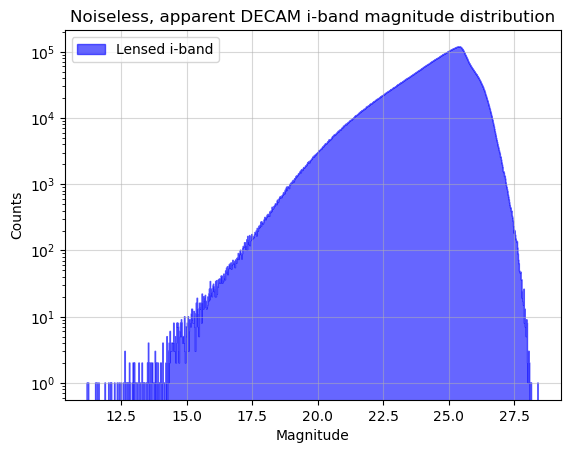

In [16]:
bounds = (np.min(lens_ap_mag_i), np.max(lens_ap_mag_i))
counts_ibuzzard, bin_edges_ibuzzard = np.histogram(lens_ap_mag_i, bins=1000, range=bounds)
bin_centers_i = 0.5 * (bin_edges_ibuzzard[:-1] + bin_edges_ibuzzard[1:])
plt.fill_between(
    bin_centers_i, counts_ibuzzard, step='mid', alpha=0.6, color='blue', label='Lensed i-band'
)
plt.yscale('log')
plt.xlabel('Magnitude')
plt.ylabel('Counts')
plt.legend()
plt.title('Noiseless, apparent DECAM i-band magnitude distribution')
plt.grid(True, alpha=0.5)

In [17]:
nside_buzzard = bc.nside_buzzard

map_low = np.zeros(hp.nside2npix(nside_buzzard))
nonzero_high = np.flatnonzero(hsc_hp_map > 0)

theta, phi = hp.pix2ang(nside_hsc, nonzero_high, nest=True)

low_pixels = hp.ang2pix(nside_buzzard, theta, phi, nest=True)
unique_low_pixels = np.unique(low_pixels)

print(f"{len(unique_low_pixels)} low-res pixels are covered.")
print("List:", unique_low_pixels)

51 low-res pixels are covered.
List: [ 64 128 150 153 154 155 156 165 167 176 271 276 277 278 282 291 292 293
 294 295 297 299 300 302 304 341 343 399 404 405 406 407 408 409 410 411
 419 420 421 422 423 424 425 426 427 428 432 490 574 639 703]


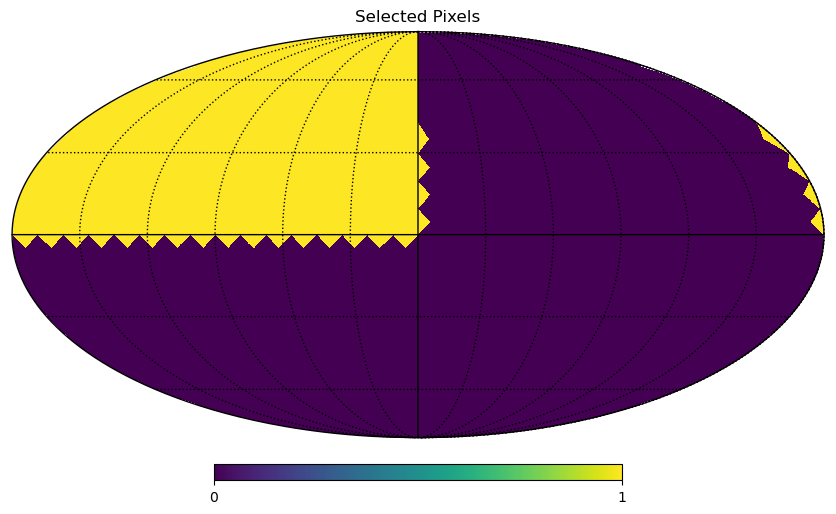

In [19]:
npix = hp.nside2npix(nside_buzzard)
hmap = np.zeros(npix)

pixels_path = Path('/global/cfs/projectdirs/desi/mocks/buzzard/buzzard_v2.0/buzzard-11/addgalspostprocess/truth')
listpix = pixels_path.glob('Chinchilla-11_cam_rs_scat_shift_lensed.*.fits')
pix_nums = sorted([int(pix.name.split('.')[1]) for pix in listpix])

# Set value 1.0 for the selected pixels
hmap[pix_nums] = 1.0

# Plot the map
hp.mollview(hmap, title="Selected Pixels", nest=True, cmap='viridis')
hp.graticule()
plt.show()

In [ ]:
## Instantiate 4 Buzzard Catalogs : each will cover a quarter of the sky
buzzard_catalogs = [
    # buzzard 1 and 2 do not exist
    BuzzardCatalog(buzzard_index=i+3, area=a) 
    for i, a in enumerate(['NW', 'NE', 'SW', 'SE'])
    ]

In [ ]:
# Now, make the mock HSC catalog.
columns = []
nonnull_hsc = np.flatnonzero(hsc_hp_map > 0)
# find the area
ra, dec = hp.pix2ang(
    nside=nside_hsc,
    ipix=nonnull_hsc,
    nest=True,
    lonlat=True,
    )
which_area_np = np.vectorize(which_area)
area_index = which_area_np(ra, dec, index=True)

### Retained buzzard columns

--------------------

Truth files : 
- ID
- RA
- DEC
- P[X,Y,Z]
- LMAG[DECam i band]

Survey mag files :
- LMAG

[0 0 0 ... 3 3 3]
2216246 201326592


## Buzzard columns

### 1] Truth files
- P[X,Y,Z] -- 3d position [Mpc/h]
- V[X,Y,Z] -- 3d velocity [km/s]
- Z_COS -- Cosmological redshift
- Z -- Redshift including RSD (Currently has a bug, should use Z in the 'surveymag' files as described below)
- MAG_R -- SDSS r-band absolute magnitude
- DIST8 -- R_delta (see addgals paper) [Mpc/h]
- M200 -- M_200 of host halo [M_sun/h]
- R200 -- R_200 of host halo [Mpc/h]
- RHALO -- Distance to nearest halo [Mpc/h]
- HALOID -- Halo id of host halo
- CENTRAL -- True for central galaxies
- SEDID -- SDSS training set index for SED assigned to galaxy
- TMAG -- Noiseless, unlensed, grizy apparent magnitudes in DECAM bandpasses [mag]
- AMAG -- Noiseless, unlensed, grizy absolute magnitudes in DECAM bandpasses [mag]
- TSIZE -- Unlensed half light radius [arcsec]
- TE -- Unlensed ellipticities
- COMOVING_SIZE -- Comoving size [Mpc]
- ID -- Unique galaxy ID
- TRA -- Unlensed RA [deg]
- TDEC -- Unlensed dec [deg]
- EPSILON -- Lensed ellipticities
- SIZE -- Lensed size [arcmin]
- KAPPA -- Convergence
- MU -- Magnification
- W -- Rotation
- GAMMA1 -- True gravitational shear along local RA direction
- GAMMA2 -- True gravitational shear along local DEC direction
- DEC -- Lensed DEC [deg]
- RA -- Lensed RA [deg]
- LMAG -- Lensed apparent DECAM grizy magnitudes

### 2] Mag files

- DECAM u
- DECAM g
- DECAM r
- DECAM i
- DECAM z
- DECAM Y
- Vista Z
- Vista Y
- Vista J
- Vista H
- Vista K
- Rubin LSST u
- Rubin LSST g
- Rubin LSST r
- Rubin LSST i
- Rubin LSST z
- Rubin LSST y
- WFIRST Y
- WFIRST J
- WFIRST H
- WFIRST K
- WISE W1
- WISE W2
- TMAG -- Noiseless, unlensed apparent magnitudes [mag]
- AMAG -- Noiseless, unlensed absolute magnitudes [mag]
- LMAG -- Noiseless, lensed apparent magnitudes [mag]
- OMAG -- Not currently used
- OMAGERR -- Not currently used
- FLUX -- Not currently used
- IVAR -- Not currently used
- Z -- Redshift including RSD (Use this instead of the redshift in the truth files!)